In [35]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt

#reload and preprocess data
df=pd.read_csv('../data/Loan_default.csv')

x=df.drop(['Default', 'LoanID'], axis=1)
y=df['Default']

cat_cols = ['Education', 'EmploymentType', 'MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']

le = LabelEncoder()
for col in cat_cols:
    x[col]=le.fit_transform(x[col])

x_train, x_test, y_train, y_test, = train_test_split(
    x,y,test_size=0.2, random_state=42, stratify=y
)

print('Data ready!')

Data ready!


In [36]:
#train lightGBM model
model=lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

model.fit(x_train, y_train)

print('Model trained!')

[LightGBM] [Info] Number of positive: 23722, number of negative: 180555
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1307
[LightGBM] [Info] Number of data points in the train set: 204277, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Model trained!


In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred = model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)[:,1]

print('ROC-AUC:', roc_auc_score(y_test,y_pred_prob))
print()
print(classification_report(y_test,y_pred))

ROC-AUC: 0.7546065589887807

              precision    recall  f1-score   support

           0       0.94      0.71      0.81     45139
           1       0.23      0.66      0.34      5931

    accuracy                           0.70     51070
   macro avg       0.59      0.69      0.58     51070
weighted avg       0.86      0.70      0.75     51070



predict_proba — gives a probability, like 0.73. "This person has a 73% chance of defaulting". The [:, 1] means take the probability for class 1 (default) only.

ROC-AUC: 0.75 — the model is reasonably good at distinguishing defaulters from non-defaulters. Anything above 0.7 is decent, above 0.8 is good. We'll try to improve this.
For class 0 (non-default):

Precision 0.94 — when it predicts no default, it's right 94% of the time
Recall 0.71 — it correctly catches 71% of actual non-defaulters

For class 1 (default):

Precision 0.23 — when it predicts default, it's only right 23% of the time
Recall 0.66 — it catches 66% of actual defaulters

The key insight here — in fintech, recall for class 1 matters most. Missing a real defaulter (false negative) costs the bank money. The model catches 66% of defaulters which is okay but not great.
The low precision (0.23) means lots of false alarms — good borrowers getting flagged as risky. That's also costly but less so than missing actual defaulters.

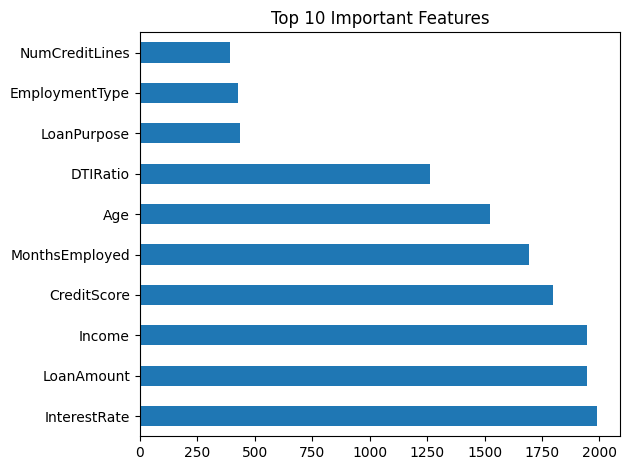

In [38]:
feat_imp = pd.Series(model.feature_importances_, index=x_train.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

Top predictors of loan default:

InterestRate — strongest signal by far, consistent with our EDA finding
LoanAmount — bigger loans = more risk
Income — lower income = higher default risk
CreditScore — as expected
MonthsEmployed — job stability matters
Age — younger borrowers default more

Weak predictors:

LoanPurpose, EmploymentType, NumCreditLines — barely useful, model barely relies on them

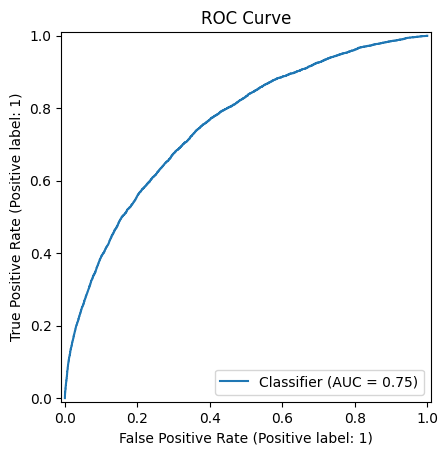

In [40]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

#roc curve
RocCurveDisplay.from_predictions(y_test, y_pred_prob)
plt.title('ROC Curve')
plt.show()

The curve shows the tradeoff between catching real defaulters (True Positive Rate) vs falsely flagging good borrowers (False Positive Rate)
A perfect model would hug the top left corner
A useless random model would be a diagonal straight line

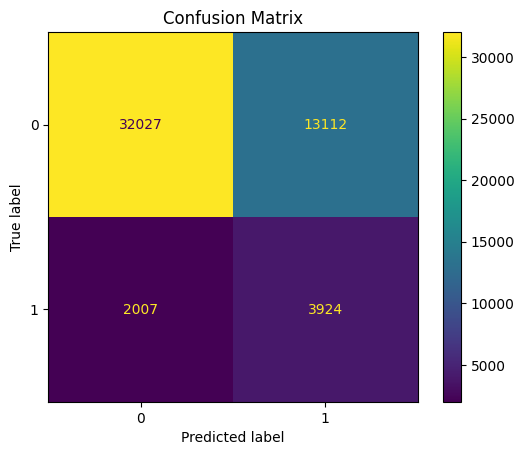

In [41]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()


32,027 — correctly predicted non-defaulters (True Negatives)
3,924 — correctly predicted defaulters (True Positives) 
13,112 — good borrowers wrongly flagged as defaulters (False Positives) — costly but less so
2,007 — actual defaulters the model missed (False Negatives) — most costly to the bank